In [11]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Data Loading 

In [2]:
def load_data(path="/kaggle/input/competitions/titanic/train.csv"):
    df = pd.read_csv(path)
    X = df.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'])
    y = df['Survived']
    return train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test = load_data()

# Preprocessing Pipeline

In [3]:
# Define which columns are numeric and which are categorical

numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Pclass', 'Sex', 'Embarked']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Model Training Automation

In [4]:
models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000)
}

best_accuracy = 0
best_model_name = ""

for name, model in models.items():
    # Create the full pipeline: Preprocessing + Model
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', model)])
    
   
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"Model: {name} | Accuracy: {acc:.4f}")
    
    # Save the best model
    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = name
        joblib.dump(clf, 'best_titanic_model.pkl')

Model: RandomForest | Accuracy: 0.8156
Model: LogisticRegression | Accuracy: 0.7989


# Load the saved production pipeline


In [7]:
model = joblib.load('/kaggle/working/best_titanic_model.pkl')


test_df = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

passenger_ids = test_df['PassengerId']
X_test_kaggle = test_df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

predictions = model.predict(X_test_kaggle)

submission = pd.DataFrame({
    "PassengerId": passenger_ids,
    "Survived": predictions
})

submission.to_csv('submission.csv', index=False)

# Train vs production

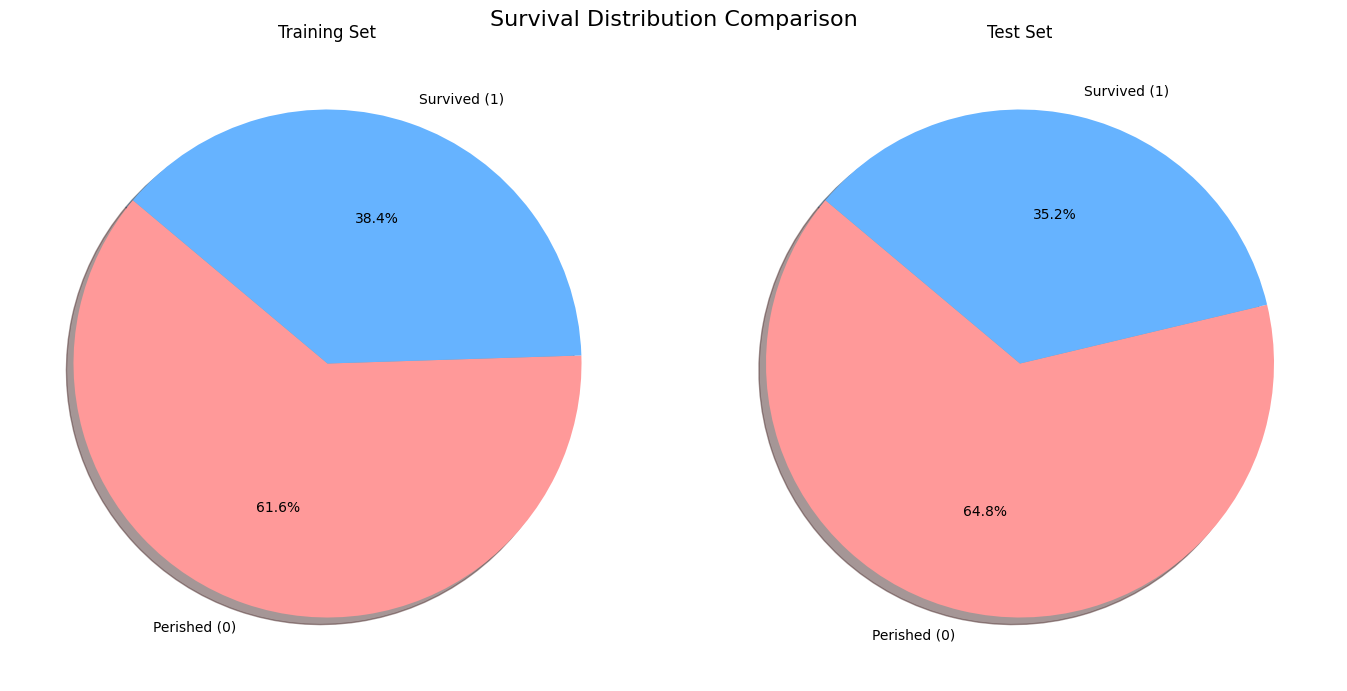

<Figure size 640x480 with 0 Axes>

In [23]:
def plot_train_vs_test_pie(train_df, submission_df):

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    
    labels = ['Perished (0)', 'Survived (1)']
    colors = ['#ff9999','#66b3ff']
    
    train_counts = train_df['Survived'].value_counts().sort_index()
    test_counts = submission_df['Survived'].value_counts().sort_index()
    
    axes[0].pie(train_counts, labels=labels, autopct='%1.1f%%', 
                startangle=140, colors=colors, shadow=True)
    axes[0].set_title('Training Set')
    
    axes[1].pie(test_counts, labels=labels, autopct='%1.1f%%', 
                startangle=140, colors=colors, shadow=True)
    axes[1].set_title('Test Set')
    
    plt.suptitle('Survival Distribution Comparison', fontsize=16)
    plt.tight_layout()
    plt.show()

train_df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
plot_train_vs_test_pie(train_df, submission)
plt.savefig('survival_comparison_pies.png')